# AIRHARP2 (ER2) File 1

In [1]:
!pip install earthaccess nasa-pace-data-reader --quiet

In [2]:
import earthaccess as ea 
import os
import numpy as np
from pathlib import Path
from nasa_pace_data_reader import L1
from nasa_pace_data_reader import plot
import warnings
warnings.filterwarnings("ignore")
import importlib
import shutil
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import h5py

In [4]:
original = "ER2/PACEPAX-AH2MAP-L1C_ER2_20240926T202945_R0.nc" #20:29 timestamp
bounding_box = (-119.78, 39.39, -119.53, 40.19)  # (lower_left_lon, lower_left_lat, upper_right_lon, upper_right_lat)
timestamp = Path(original).stem.split("_")[2]  
fileName = str(Path(original).parent / f"PACE_HARP2.{timestamp}.L1C.V3.5km.nc")

shutil.copy(original, fileName)
print(f"Copied to: {fileName}")

Copied to: ER2/926/PACE_HARP2.20240926T202945.L1C.V3.5km.nc


In [5]:
l1c = L1.L1C()
l1c_dict = l1c.read(fileName)
l1c_dict.keys()

Reading HARP2 data from ER2/926/PACE_HARP2.20240926T202945.L1C.V3.5km.nc


dict_keys(['date_time', 'latitude', 'longitude', 'scattering_angle', 'solar_zenith_angle', 'solar_azimuth_angle', 'sensor_zenith_angle', 'sensor_azimuth_angle', 'height', 'rotation_angle', '_units', 'i', 'q', 'u', 'dolp', 'F0', 'view_angles', 'intensity_wavelength'])

In [ ]:
target_lat = bounding_box[1] 
target_lon = bounding_box[2] 

dist = np.sqrt(
    (l1c_dict['latitude']  - target_lat)**2 +
    (l1c_dict['longitude'] - target_lon)**2
) #distance formula

pixel = list(np.unravel_index(np.argmin(dist), dist.shape)) 

print(f"Closest HARP2 pixel: {pixel}")
print(f"lat={l1c_dict['latitude'][pixel[0], pixel[1]]:.4f}, lon={l1c_dict['longitude'][pixel[0], pixel[1]]:.4f}")
pix1, pix2 = pixel

Closest HARP2 pixel: [0, 119]
lat=39.3896, lon=-119.5313


Instrument set to HARP2
Instrument set to HARP2
setting dpi to 256 ppi
...Setting the subplots with number of bands 4 and number of variables 4


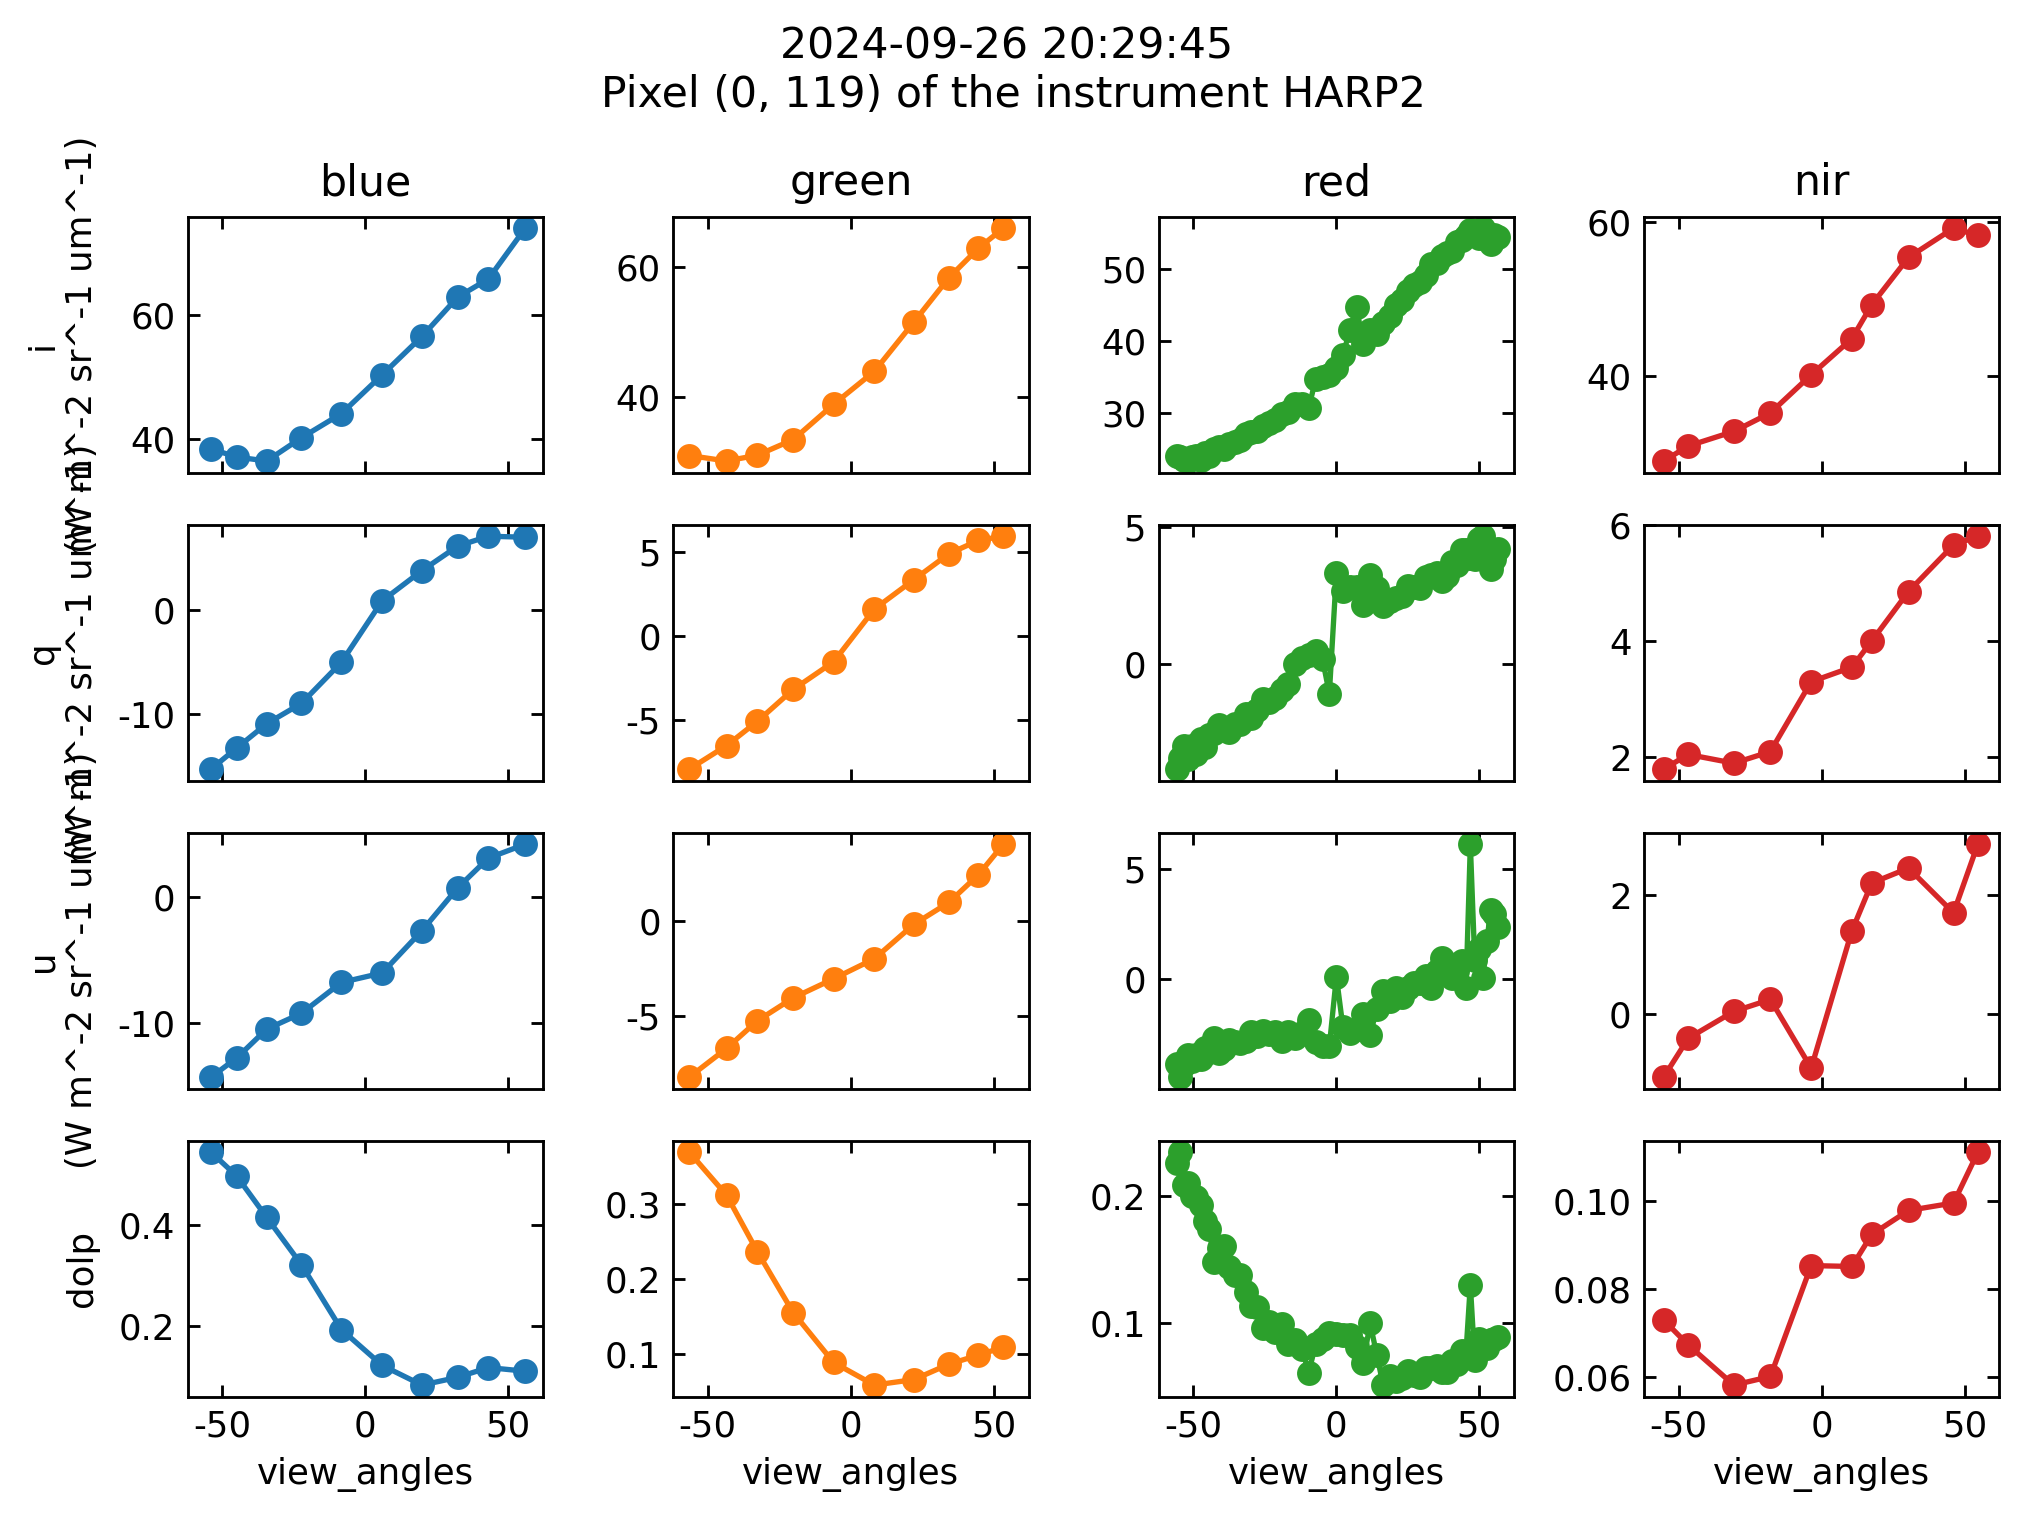

...Setting the subplots with number of bands 4 and number of variables 4


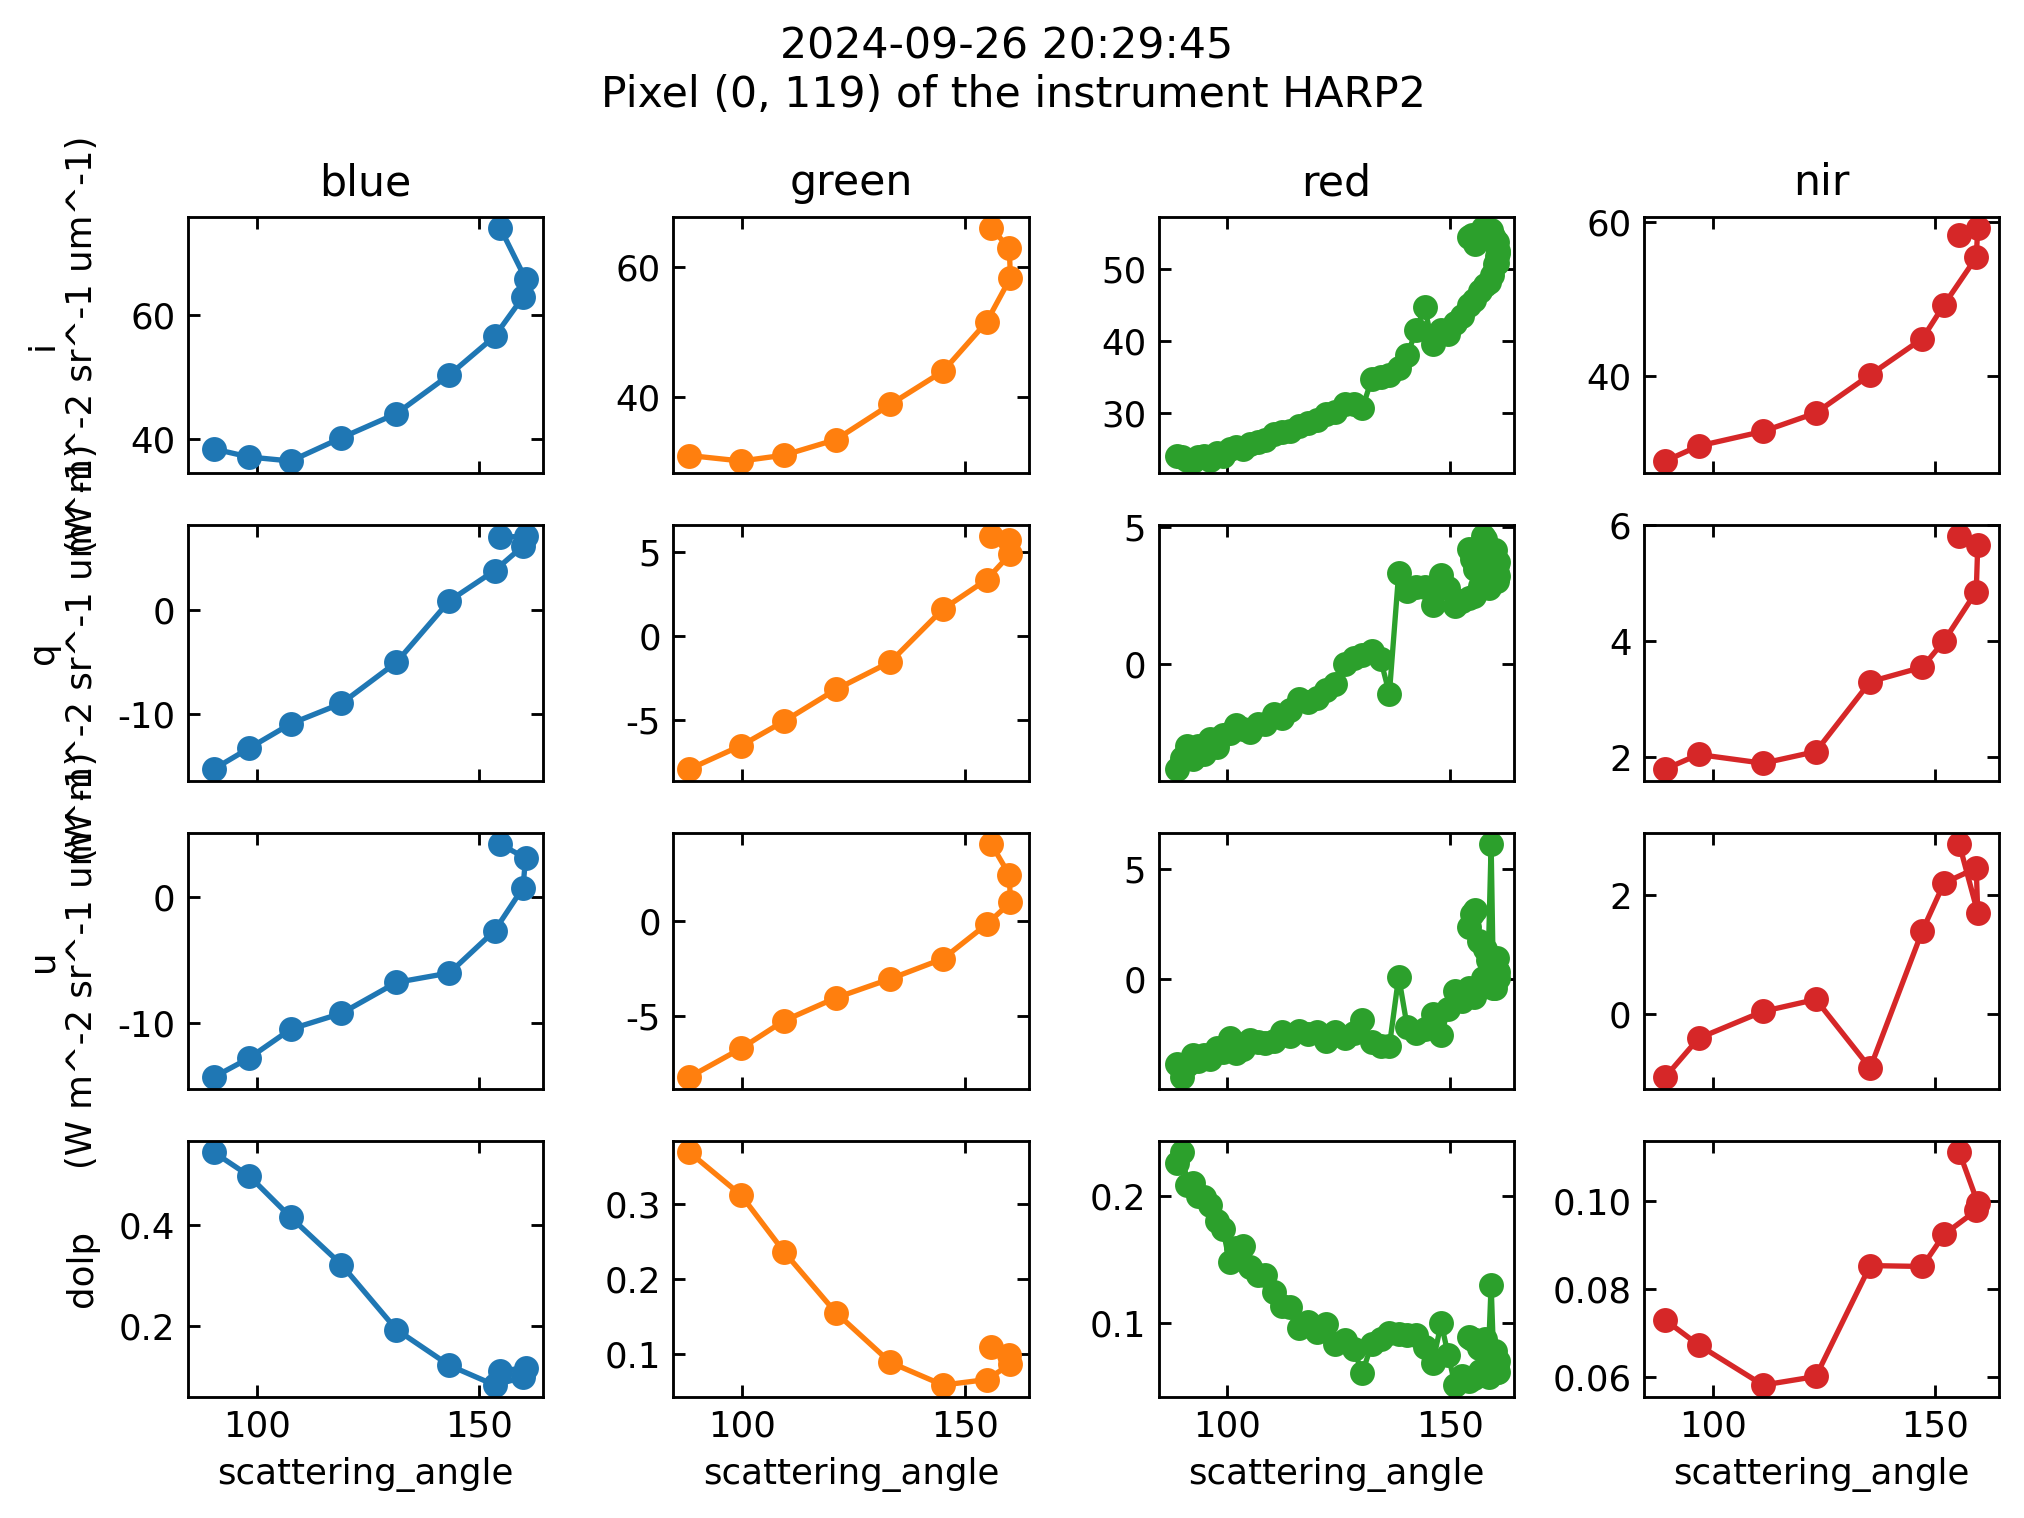

In [7]:
plt_ = plot.Plot(l1c_dict)
plt_.setInstrument()
plt_.setDPI(256)
# plot all vars and bands
plt_.plotPixelVars(pixel[0], pixel[1], xAxis='view_angles')
plt_.plotPixelVars(pixel[0], pixel[1], xAxis='scattering_angle')

...Centering the projection at lon:-119.62, lat:39.664
...Creating a new figure


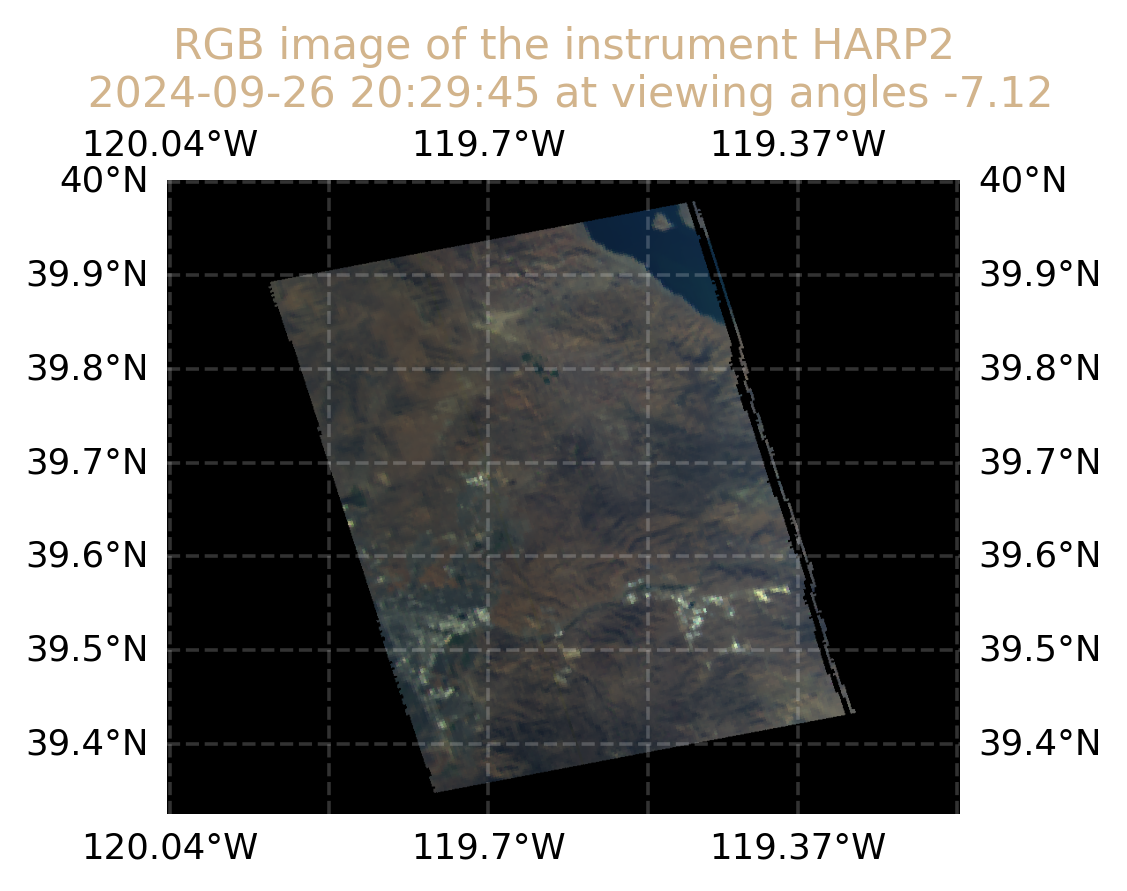

...Centering the projection at lon:-119.62, lat:39.664
...Creating a new figure


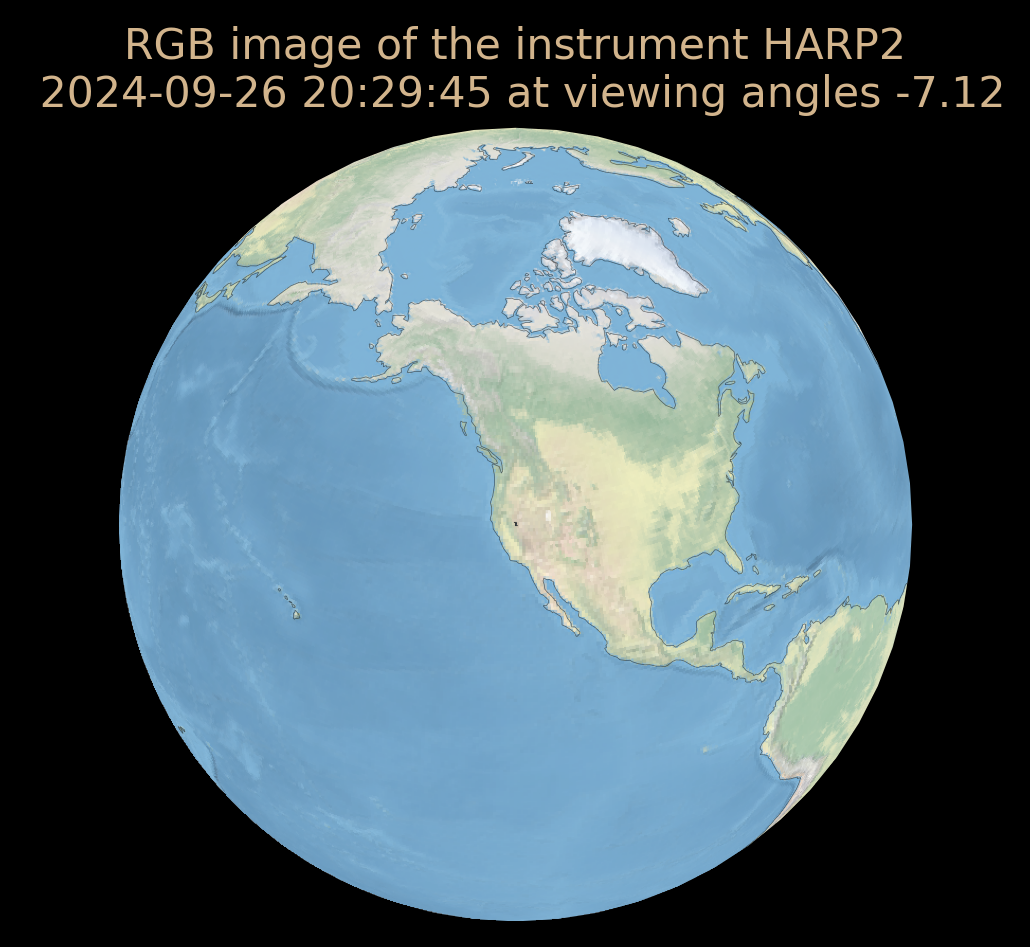

In [8]:
# plot RGB in default plate carree projection
plt_.projectedRGB()

# plot RGB in Orthographic projection
plt_.projectedRGB(proj='Orthographic')

In [9]:
with h5py.File(original, "r") as f:
    lat         = f["geolocation_data/latitude"][:]
    lon         = f["geolocation_data/longitude"][:]
    dolp_raw = f["observation_data/dolp"][:]
    view_angles = f["sensor_views_bands/sensor_view_angle"][:].flatten()
    wavelengths = f["sensor_views_bands/polarization_wavelength"][:].flatten()

dolp = np.where(dolp_raw == -32767, np.nan, dolp_raw * 5e-05) #scales data manually the way nasa-pace-data-reader does
#and masks out NaN (-32767) data

...Band set to blue
...Band set to green
...Band set to red
...Band set to nir


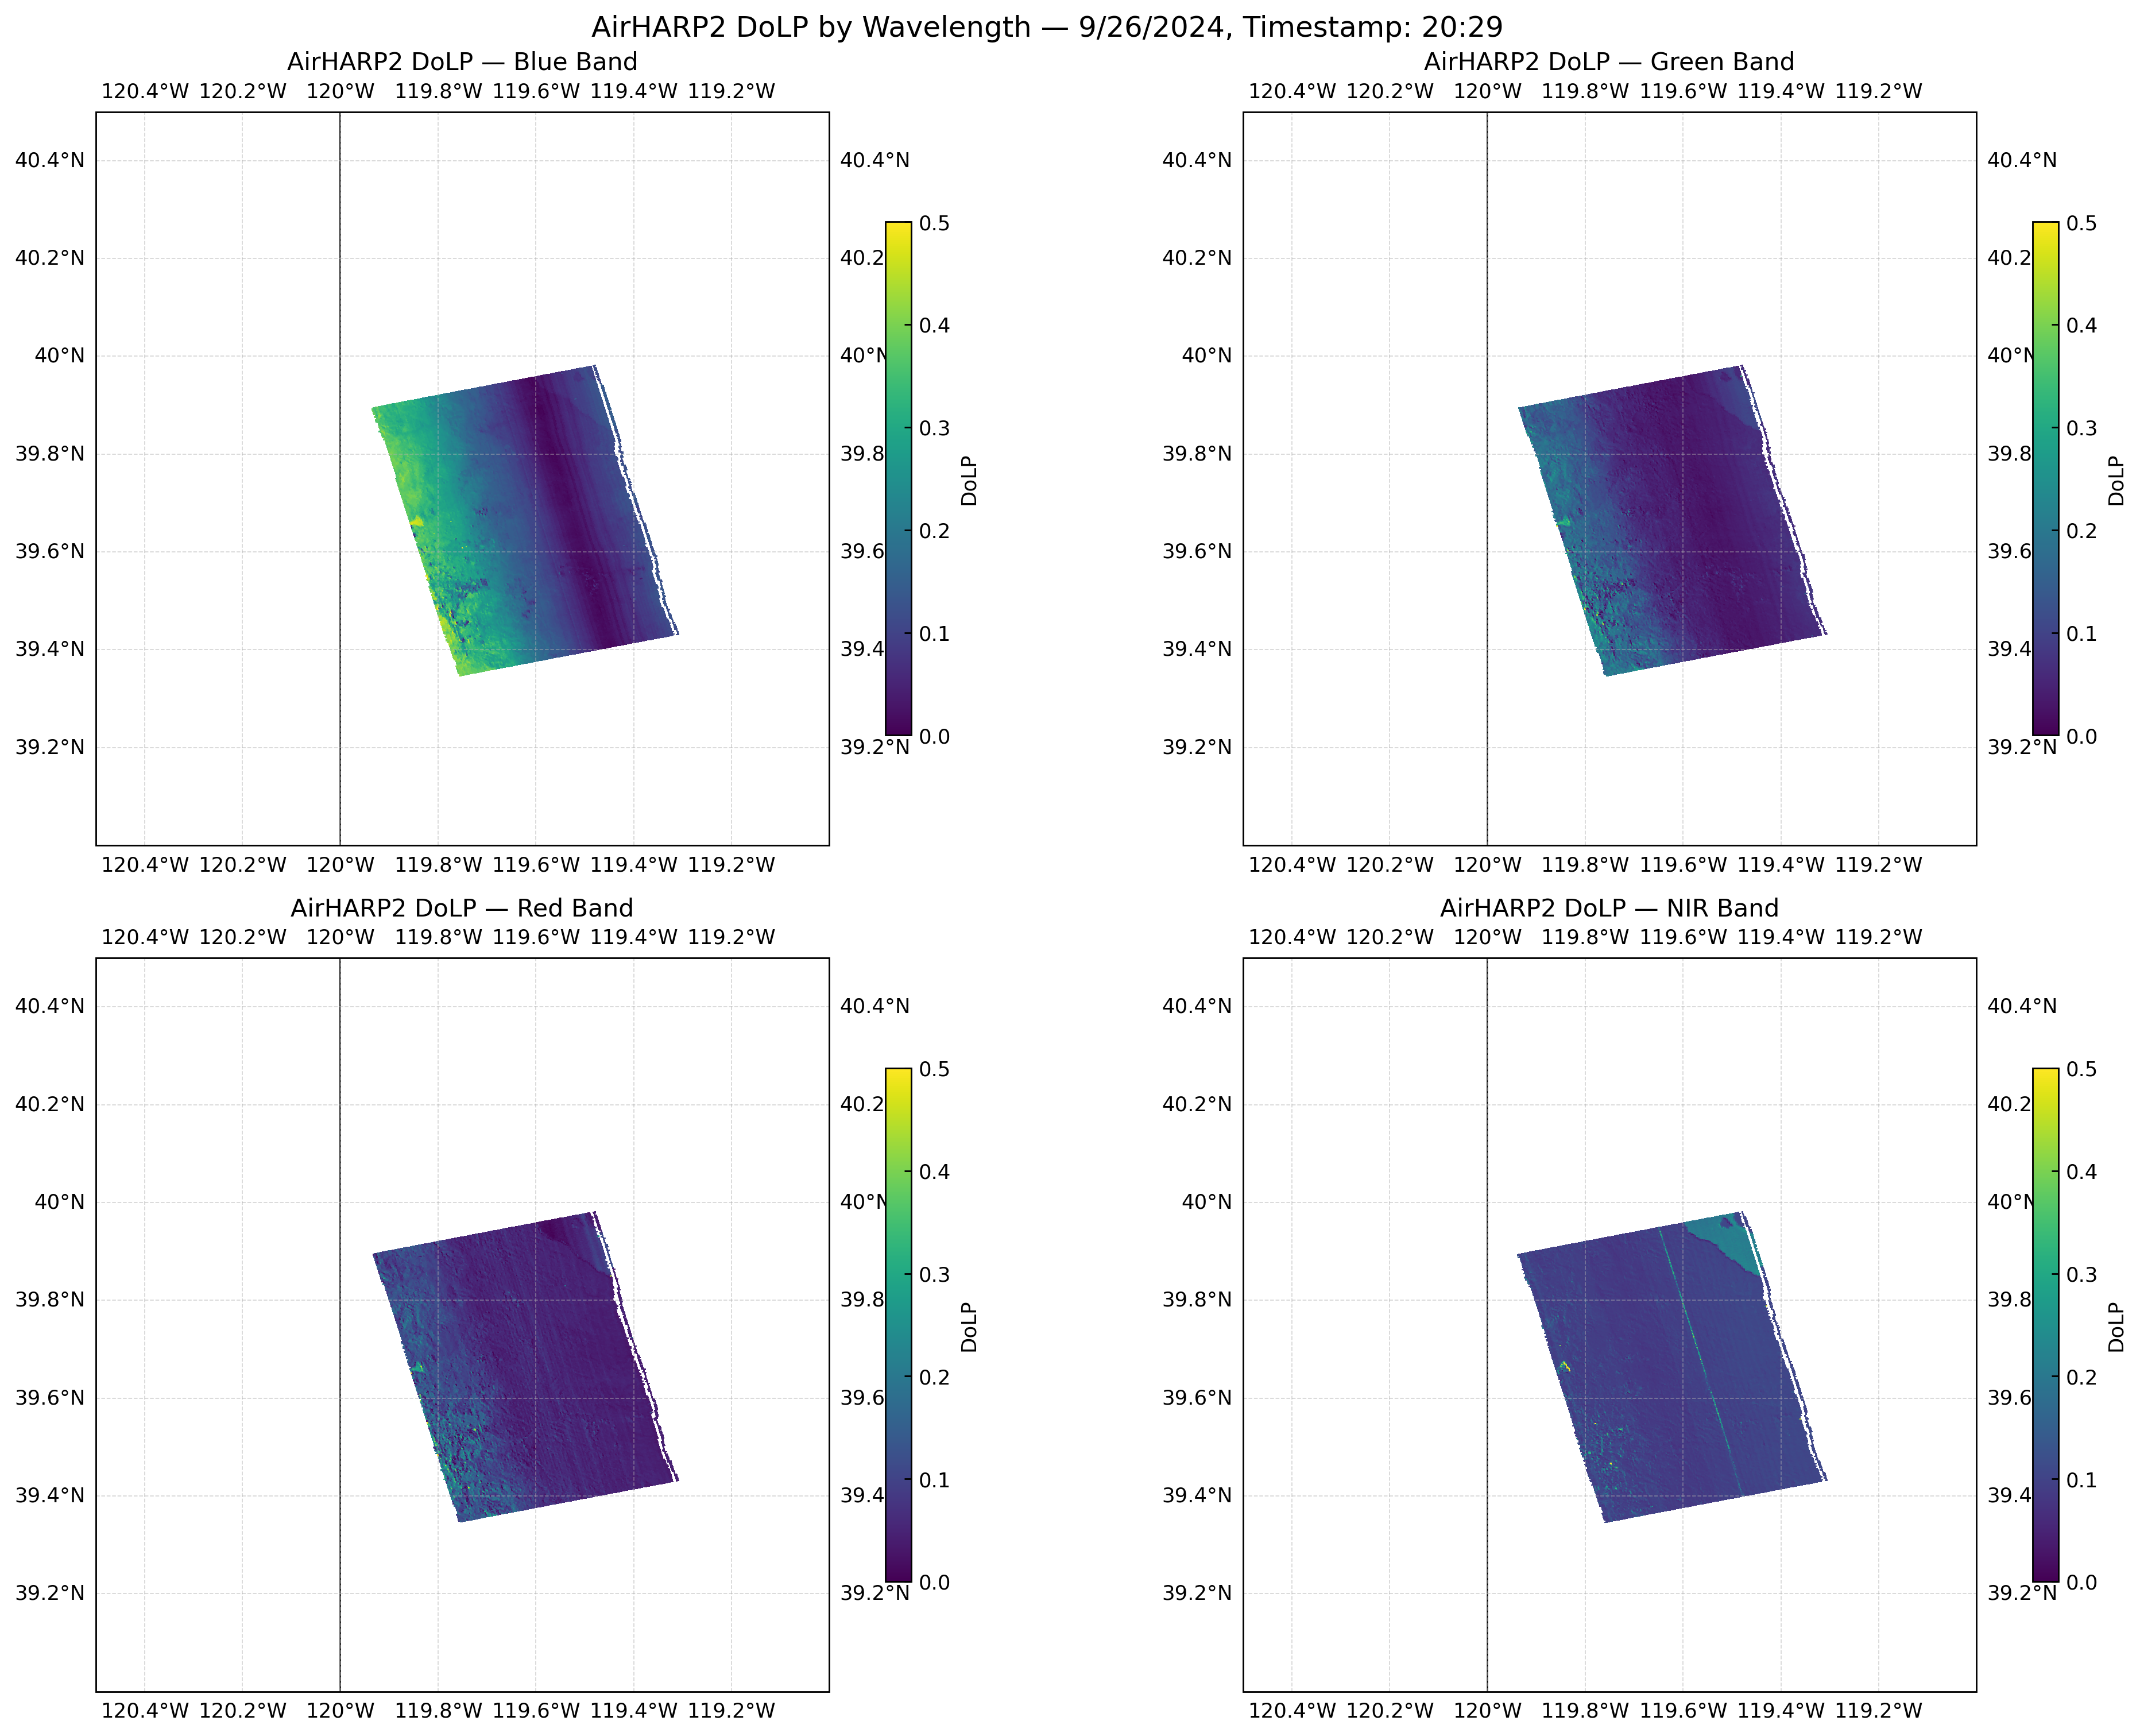

In [10]:
bands = ['Blue', 'Green', 'Red', 'NIR']
fig, axes = plt.subplots(2, 2, figsize=(16, 12),subplot_kw={"projection": ccrs.PlateCarree()})

for ax, band in zip(axes.flatten(), bands):
    plt_.setBand(band)
    nadir_idx = plt_.bandAngles[len(plt_.bandAngles)//2] #looking straight down
    dolp_map = l1c_dict['dolp'][:, :, nadir_idx].squeeze()

    ax.set_extent([-120.5, -119.0, 39.0, 40.5])
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)
    sc = ax.pcolormesh(lon, lat, dolp_map, cmap="viridis", vmin=0, vmax=0.5, transform=ccrs.PlateCarree())
    plt.colorbar(sc, ax=ax, label="DoLP", shrink=0.7)
    ax.set_title(f"AirHARP2 DoLP — {band} Band")

fig.suptitle("AirHARP2 DoLP by Wavelength — 9/26/2024, Timestamp: 20:29", fontsize=14)
plt.tight_layout()
plt.show()